In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

In [2]:
data = pd.read_csv('/Users/rgao76/Documents/DiffTasks/spatial_correlation_2025/Data/all_data.csv')
data = data[~data['ROI'].str.contains('AngG')]
data['Version1'] = data['Version1'].replace({'V6': 'V4', 'V4': 'V5', 'V5': 'V6'})
data['Version2'] = data['Version2'].replace({'V6': 'V4', 'V4': 'V5', 'V5': 'V6'})

/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_32593/30986471.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/rgao76/Documents/DiffTasks/spatial_correlation_2025/Data/all_data.csv')


In [3]:
def plot_data(d, axs, vmin=0.0, vmax=1., cbar=False, cbar_ax=None,
              title=None, xticklabels=False, yticklabels=False):
    d = d.copy()
    d['Task1_Effect1'] = d['Version1'] + ' ' + d['Effect1']
    d['Task2_Effect2'] = d['Version2'] + ' ' + d['Effect2']
    d['Correlation'] = np.tanh(d['FisherZ'])

    def _prepare_data(df, order_row, order_col):
        df = df[df['Task1_Effect1'].isin(order_col) & df['Task2_Effect2'].isin(order_row)].reset_index(drop=True)
        for i in range(len(df)):
            if order_col.index(df.loc[i, 'Task1_Effect1']) > order_row.index(df.loc[i, 'Task2_Effect2']):
                df.loc[i, 'Task1_Effect1'], df.loc[i, 'Task2_Effect2'] = df.loc[i, 'Task2_Effect2'], df.loc[i, 'Task1_Effect1']
        df = df.groupby(['Task1_Effect1', 'Task2_Effect2'])['Correlation'].mean().reset_index()
        tbl = df.pivot(index='Task2_Effect2', columns='Task1_Effect1', values='Correlation')
        return tbl

    def _plot_heatmap_panel(ax, tbl, order_row, order_col, mask=True,
                            order_row_names=None, order_col_names=None):
        tbl = tbl.reindex(index=order_row, columns=order_col)
        cmap = mpl.colormaps.get_cmap('OrRd')
        cmap.set_bad(color='lightgrey')
        heatmap = sns.heatmap(tbl, annot=True, fmt=".2f", cbar_kws={'label': 'Fisher Z'},
                              cmap=cmap, ax=ax, 
                              xticklabels=order_col_names if xticklabels else False,
                              yticklabels=order_row_names if yticklabels else False, 
                              square=False,
                              vmin=vmin, vmax=vmax, cbar=cbar, cbar_ax=cbar_ax,
                              annot_kws={'fontsize': 5})
        if cbar:
            cb = heatmap.collections[0].colorbar
            cb.ax.tick_params(labelsize=6)
            cb.ax.set_ylabel('Fisher Z', fontsize=6)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)

        if mask:
            white_mask = np.tril(np.ones(tbl.shape))
            white_mask[white_mask == 1] = np.nan
            sns.heatmap(white_mask, cmap='binary', ax=ax, cbar=False, vmin=0, vmax=1,
                        xticklabels=order_col_names if xticklabels else False, 
                        yticklabels=order_row_names if yticklabels else False, 
                        square=False)
        
        ax.xaxis.set_tick_params(length=0.)
        ax.yaxis.set_tick_params(length=0.)

    # Plot SS
    order_ss = ['V1 S', 'V2 S', 'V3 S', 'V4 S', 'V5 S', 'V6 S']
    order_ss_names = [
        'V1 (button press)', 'V2 (hard memory probe)', 'V3 (easy memory probe)',
        'V4 (button press)', 'V5 (comprehension q)', 'V6 (sentiment q)'
    ]
    versions = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    tbl_ss = _prepare_data(d, order_ss, order_ss)
    _plot_heatmap_panel(axs[0], tbl_ss, order_ss, order_ss,
                        order_row_names=order_ss_names,
                        order_col_names=versions)

    # Plot NS
    order_s = ['V1 S', 'V2 S', 'V3 S', 'V4 S', 'V5 S', 'V6 S']
    order_n = ['V1 N', 'V2 N', 'V3 N', 'V4 N', 'V5 N', 'V6 N']
    order_nn_names = [
        'V1 (button press)', 'V2 (hard memory probe)', 'V3 (easy memory probe)',
        'V4 (hard memory probe)', 'V5 (hard memory probe)', 'V6 (hard memory probe)'
    ]
    order_ns = order_s + order_n
    tbl_ns = _prepare_data(d, order_ns, order_ns)
    _plot_heatmap_panel(axs[2], tbl_ns, order_n, order_s, mask=False,
                        order_row_names=order_nn_names,
                        order_col_names=versions)
    axs[2].set_xlabel("")
    axs[2].set_ylabel("")

    # Plot NN
    order_nn = order_n
    tbl_nn = _prepare_data(d, order_nn, order_nn)
    _plot_heatmap_panel(axs[3], tbl_nn, order_nn, order_nn,
                        order_row_names=order_nn_names,
                        order_col_names=versions)

    # Blank panel
    axs[1].axis('off')


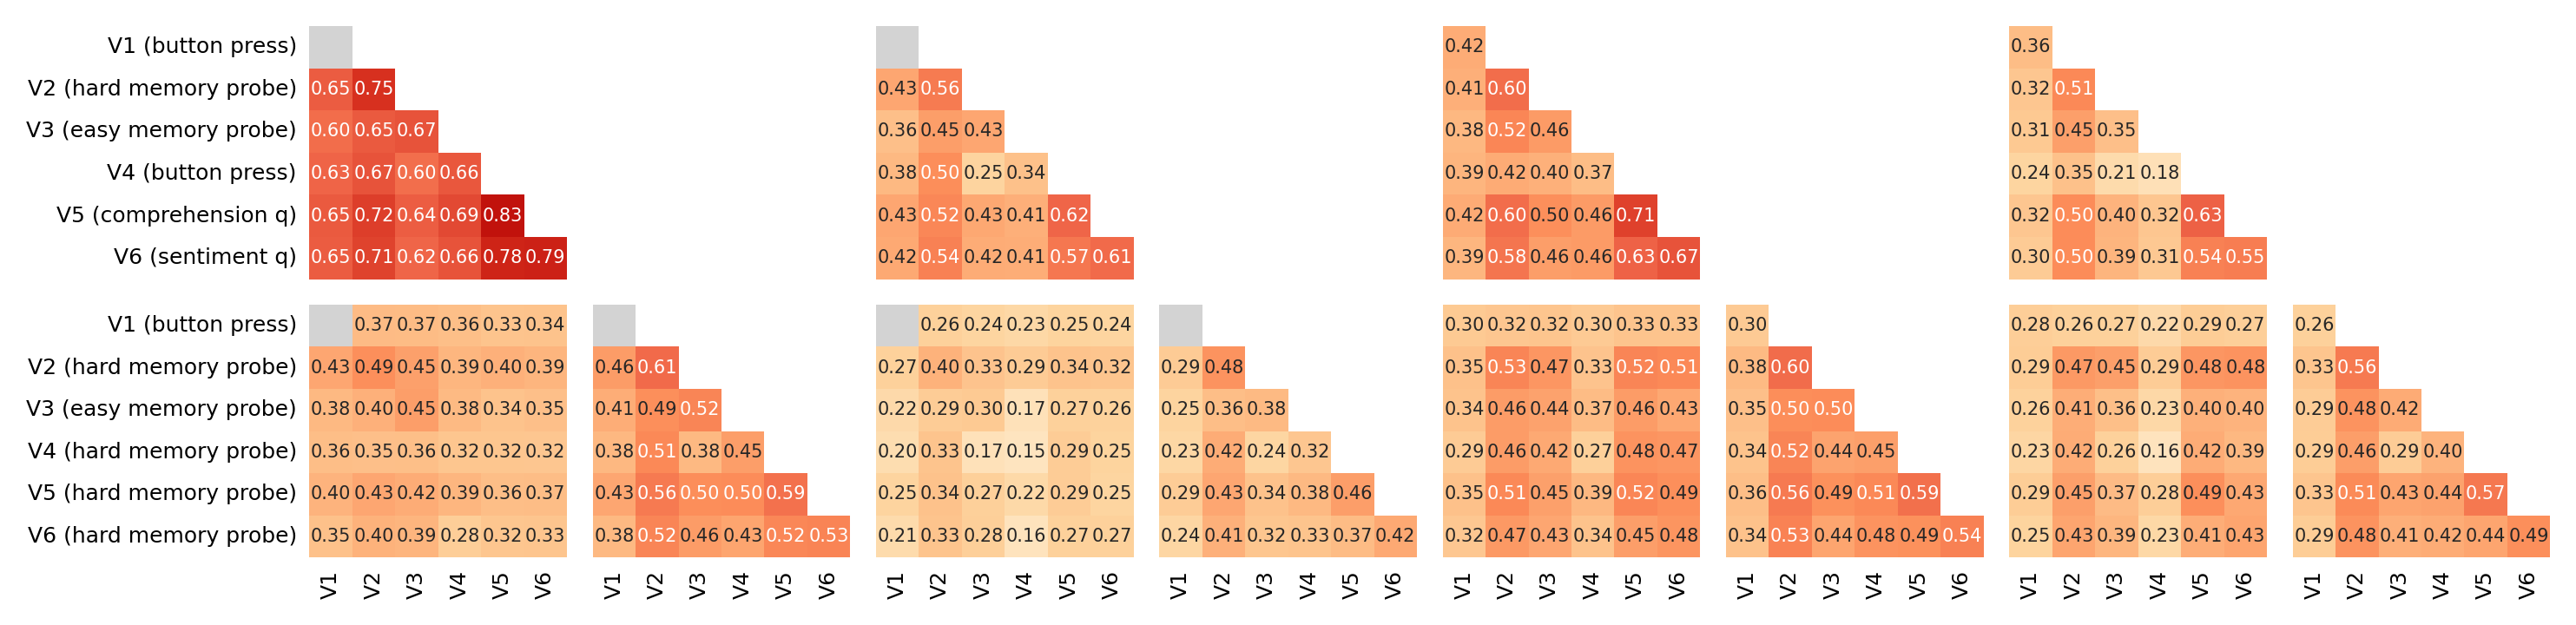

In [4]:
configs = [
    ('language', 'LH'),
    ('language', 'RH'),
    ('MD',       'LH'),
    ('MD',       'RH'),
]

output_path = '/Users/rgao76/Documents/DiffTasks/spatial_correlation_2025/Figures/spcorr_networks.png'

fig, axes = plt.subplots(2, 8, figsize=(10, 2.5), dpi=300, sharex='col', sharey='row')

for i, (system, hemisphere) in enumerate(configs):
    subset = data[(data['System'] == system) & (data['Hemisphere'] == hemisphere)]
    if system == 'language':
        subset = subset[subset['Localizer'] == 'V1']

    # Assign 4 axes for each set: SS, blank, NS, NN
    col_start = i * 2
    ax_block = [axes[0, col_start], axes[0, col_start + 1],
                axes[1, col_start], axes[1, col_start + 1]]

    plot_data(
        subset.reset_index(drop=True),
        ax_block,
        xticklabels=True,
        yticklabels=True
    )

fig.tight_layout(w_pad=0.1, h_pad=0.1)
fig.subplots_adjust(wspace=0.1, hspace=0.1)
fig.savefig(output_path, dpi=300, transparent=True)


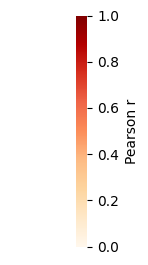

In [5]:
# Colorbar
import matplotlib as mpl
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(1,3))
cmap = mpl.colormaps.get_cmap('OrRd')
norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(sm, ax=ax, orientation='vertical')
cb.set_label('Pearson r', fontsize=10)
cb.outline.set_visible(False)
ax.set_axis_off()
fig.savefig('/Users/rgao76/Documents/DiffTasks/spatial_correlation_2025/Figures/spcorr_colorbar.png', dpi=300, bbox_inches='tight', transparent=True)